# RQ3: Detect using custom DL models

In [2]:
#from google import genai
#from google.genai import types
import os
import numpy as np
import pandas as pd
import configparser
from tqdm import tqdm
import ast
import time
#from vertexai.preview import tokenization

#import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, matthews_corrcoef, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, KFold, LeaveOneOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
#from imblearn.over_sampling import RandomOverSampler

from os import name
# import tensorflow as tf
# import tensorflow_addons as tfa
# from tensorflow.keras import layers, Model, Input
# import numpy as np
# import tensorflow.keras.backend as K

random_seed = 42

import warnings
warnings.filterwarnings('ignore')


config = configparser.ConfigParser()
config.read(".config")
HF_TOKEN = config["API_KEYS"]["HF_TOKEN"]

## Split train test data

In [ ]:
df_emb = pd.read_csv("./data/Embeddings/MsgDiff.csv")
df_emb["Embeddings"] = df_emb["Embeddings"].apply(ast.literal_eval)

g = pd.read_csv("./data/GoldSet.csv")
tangled_buggy = df_emb[df_emb['Hash'].isin(g['CommitHash'])]
tangled_buggy["Similarity"] = tangled_buggy["Label"].apply(lambda x: 0 if x=="NotBuggy" else 1)

true_buggy_notbuggy = df_emb[~df_emb['Hash'].isin(g['CommitHash'])]
true_buggy_notbuggy["Similarity"] = 1

df_emb = pd.concat([tangled_buggy, true_buggy_notbuggy])

dummy_x = np.arange(0,df_emb.shape[0])
dummy_df = pd.DataFrame({"X":dummy_x, "Y":df_emb["Similarity"].to_list()})
train_indx, test_indx, _, _ = train_test_split(dummy_df["X"], dummy_df["Y"], test_size=0.2, stratify=dummy_df["Y"])
train_indx.to_csv("./data/Embeddings/train_index.csv", index = False)
test_indx.to_csv("./data/Embeddings/test_index.csv", index = False)

## Gemini Embedding Collector

In [ ]:
class GeminiEmbeddingGenerator:
    def __init__(self, model_name, embedding_type):
        self.model_name = model_name
        self.embedding_type = embedding_type
        self.__setup()

    def __setup(self):
        config = configparser.ConfigParser()
        config.read(".config")
        GEMINI_API_KEY = config["API_KEYS"]["GEMINI_API_KEY"]

        self.__client = genai.Client(api_key=GEMINI_API_KEY)
        self.__tokenizer = tokenization.get_tokenizer_for_model("gemini-1.5-flash-001")
    
    def get_token_count(self, text):
        return self.__tokenizer.count_tokens(text).total_tokens 

    def get_embeddings(self, text):
        #return np.arange(1,768,1).tolist()
        result = self.__client.models.embed_content(
                        model=self.model_name ,
                        contents=text,
                        config=types.EmbedContentConfig(task_type=self.embedding_type)
                )
        return result.embeddings[0].values

## Simple classificaton task using LLM embeddings

In [24]:
df = pd.read_csv("./data/Complete_GoldSet.csv")
df['text'] = "CommitMessage: " + df['CommitMessage'] + "\nDiff:\n" +  df['Diff']

### Embedding Collection - No Need to Run

In [ ]:
egen = GeminiEmbeddingGenerator("text-embedding-004", "CLASSIFICATION")
id = []
X = []
Y = []
for _, row in tqdm(df.iterrows()):
    emb = egen.get_embeddings(row['text'])
    id.append(row["CommitHash"])
    X.append(emb)
    Y.append(row["Decision"])
    time.sleep(0.25)
df_emb = pd.DataFrame(data={"Hash": id, "Embeddings": X, "Label": Y})
df_emb['Embeddings'] = df_emb['Embeddings'].astype('object')
df_emb.to_csv("./data/Embeddings/MsgDiff.csv", index=False)

arr_x = np.array(X)
np.save("./data/Embeddings/MsgDiff.npy", arr_x)

### Training and Testing

In [25]:
df_emb = pd.read_csv("./data/Embeddings/MsgDiff.csv")
df_emb["Embeddings"] = df_emb["Embeddings"].apply(ast.literal_eval)

train_indx = pd.read_csv("./data/Embeddings/train_index.csv")["X"].to_list()
test_indx = pd.read_csv("./data/Embeddings/test_index.csv")["X"].to_list()

train = df_emb.iloc[train_indx]
test = df_emb.iloc[test_indx]

X_train = np.array([np.array(lst) for lst in train['Embeddings']])
X_test = np.array([np.array(lst) for lst in test['Embeddings']])
y_train = train['Label'].values
y_test = test['Label'].values

In [21]:
def train_test(model):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label="Buggy")
    recall = recall_score(y_test, y_pred, pos_label="Buggy")
    f1 = f1_score(y_test, y_pred, pos_label="Buggy")
    mcc = matthews_corrcoef(y_test, y_pred)

    print(type(model).__name__)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC Score: {mcc:.4f}")

    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    conf_matrix = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(conf_matrix, display_labels=["Buggy", "NotBuggy"]).plot()

#### Random Forest

RandomForestClassifier
Accuracy: 0.8159
Precision: 0.8413
Recall: 0.8196
F1 Score: 0.8303
MCC Score: 0.6294

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.84      0.82      0.83       194
    NotBuggy       0.79      0.81      0.80       159

    accuracy                           0.82       353
   macro avg       0.81      0.82      0.81       353
weighted avg       0.82      0.82      0.82       353



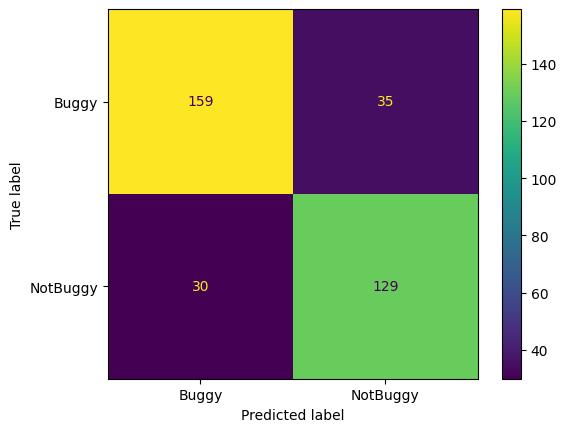

In [5]:
train_test(RandomForestClassifier(random_state=random_seed, n_jobs=-1))

#### SVC

SVC
Accuracy: 0.8839
Precision: 0.9180
Recall: 0.8660
F1 Score: 0.8912
MCC Score: 0.7684

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.92      0.87      0.89       194
    NotBuggy       0.85      0.91      0.88       159

    accuracy                           0.88       353
   macro avg       0.88      0.89      0.88       353
weighted avg       0.89      0.88      0.88       353



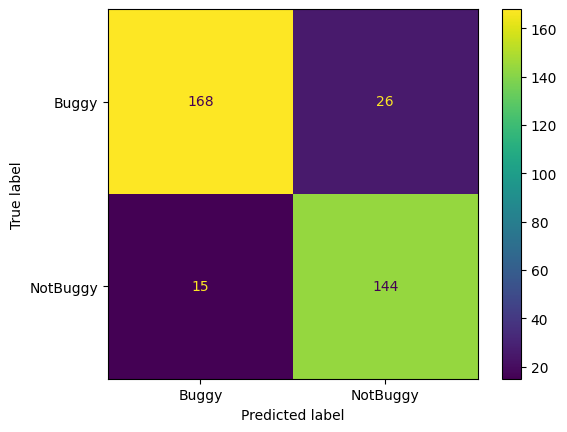

In [6]:
train_test(SVC(random_state=random_seed))

#### Decision Tree

DecisionTreeClassifier
Accuracy: 0.6856
Precision: 0.7173
Recall: 0.7062
F1 Score: 0.7117
MCC Score: 0.3660

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.72      0.71      0.71       194
    NotBuggy       0.65      0.66      0.65       159

    accuracy                           0.69       353
   macro avg       0.68      0.68      0.68       353
weighted avg       0.69      0.69      0.69       353



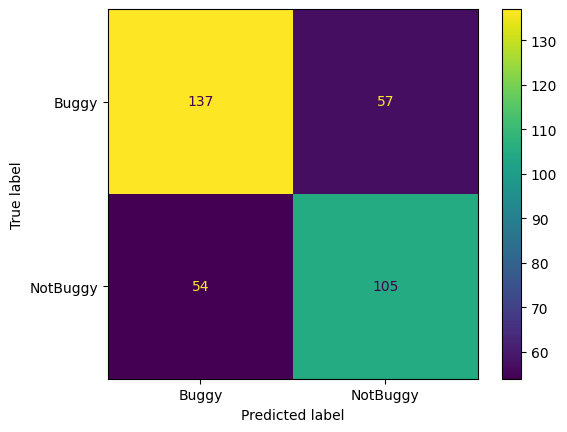

In [7]:
train_test(DecisionTreeClassifier(random_state=random_seed))

#### MLP

MLPClassifier
Accuracy: 0.8952
Precision: 0.9290
Recall: 0.8763
F1 Score: 0.9019
MCC Score: 0.7911

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.93      0.88      0.90       194
    NotBuggy       0.86      0.92      0.89       159

    accuracy                           0.90       353
   macro avg       0.89      0.90      0.89       353
weighted avg       0.90      0.90      0.90       353



/home/cs/grad/opumni/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


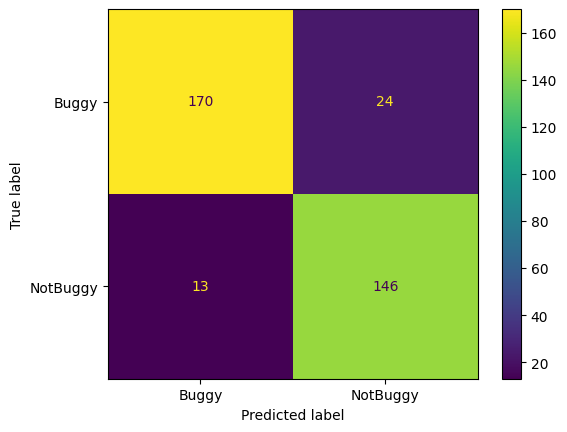

In [8]:
train_test(MLPClassifier(random_state=random_seed))

#### Leave One Out

Accuracy 0.9036281179138322 
Precision 0.8980263157894737 
Recall 0.9140625 
F1 Score 0.9059734513274337 
MCC 0.8072851031361549

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.90      0.91      0.91       896
    NotBuggy       0.91      0.89      0.90       868

    accuracy                           0.90      1764
   macro avg       0.90      0.90      0.90      1764
weighted avg       0.90      0.90      0.90      1764



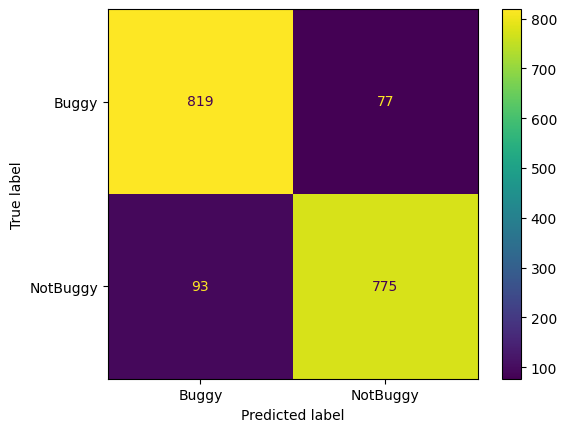

In [4]:
X = df_emb['Embeddings']
X = np.array([np.array(lst) for lst in X])

y = df_emb['Label'].values

y_preds, y_trues = [], []

cv = LeaveOneOut()
for train, test in tqdm(cv.split(X, y), total=len(X)):
    x_train = [X[i] for i in train]
    x_test = [X[test[0]]]
    y_train = [y[i] for i in train]
    y_test = [y[test[0]]]

    model = MLPClassifier(random_state=random_seed)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    y_preds.append(y_pred)
    y_trues.append(y_test[0])

print(
    "Accuracy", accuracy_score(y_trues, y_preds),
    "\nPrecision", precision_score(y_trues, y_preds, pos_label="Buggy"),
    "\nRecall", recall_score(y_trues, y_preds, pos_label="Buggy"),
    "\nF1 Score", f1_score(y_trues, y_preds, pos_label="Buggy"),
    "\nMCC", matthews_corrcoef(y_trues, y_preds),
)

print("\nClassification Report:\n", classification_report(y_trues, y_preds))
conf_matrix = confusion_matrix(y_trues, y_preds)
ConfusionMatrixDisplay(conf_matrix, display_labels=["Buggy", "NotBuggy"]).plot()


# Open Source

In [3]:
def load_data(data):
    def convert(x):
        new_x = None
        try:
            new_x = ast.literal_eval(x)
        except:
            new_x = [float(val) for val in x[1:-1].split()]

        return new_x
    
    df = pd.read_csv(data)
    df["Embeddings"] = df["Embeddings"].apply(lambda x: convert(x))

    return df

def train_test(model, data):
    if isinstance(data, str): 
        df_emb = load_data(data)
    else:
        df_emb = data
    
    train_indx = pd.read_csv("./data/Embeddings/train_index.csv")["X"].to_list()
    test_indx = pd.read_csv("./data/Embeddings/test_index.csv")["X"].to_list()
    
    train = df_emb.iloc[train_indx]
    test = df_emb.iloc[test_indx]
    
    X_train = np.array([np.array(lst) for lst in train['Embeddings']])
    X_test = np.array([np.array(lst) for lst in test['Embeddings']])
    y_train = train['Label'].values
    y_test = test['Label'].values

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label="Buggy")
    recall = recall_score(y_test, y_pred, pos_label="Buggy")
    f1 = f1_score(y_test, y_pred, pos_label="Buggy")
    mcc = matthews_corrcoef(y_test, y_pred)

    print(type(model).__name__)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC Score: {mcc:.4f}")

    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    conf_matrix = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(conf_matrix, display_labels=["Buggy", "NotBuggy"]).plot()

def loo(model, data):
    if isinstance(data, str): 
        df_emb = load_data(data)
    else:
        df_emb = data
        
    X = df_emb['Embeddings']
    X = np.array([np.array(lst) for lst in X])
    
    y = df_emb['Label'].values
    
    y_preds, y_trues = [], []
    
    cv = LeaveOneOut()
    for train, test in tqdm(cv.split(X, y), total=len(X)):
        x_train = [X[i] for i in train]
        x_test = [X[test[0]]]
        y_train = [y[i] for i in train]
        y_test = [y[test[0]]]
    
        model = MLPClassifier(random_state=random_seed)
        model.fit(x_train, y_train)
    
        y_pred = model.predict(x_test)
    
        y_preds.append(y_pred)
        y_trues.append(y_test[0])
    
    print(
        "Accuracy", accuracy_score(y_trues, y_preds),
        "\nPrecision", precision_score(y_trues, y_preds, pos_label="Buggy"),
        "\nRecall", recall_score(y_trues, y_preds, pos_label="Buggy"),
        "\nF1 Score", f1_score(y_trues, y_preds, pos_label="Buggy"),
        "\nMCC", matthews_corrcoef(y_trues, y_preds),
    )
    
    print("\nClassification Report:\n", classification_report(y_trues, y_preds))
    conf_matrix = confusion_matrix(y_trues, y_preds)
    ConfusionMatrixDisplay(conf_matrix, display_labels=["Buggy", "NotBuggy"]).plot()


## CodeBERT

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm

class CodeBERTEmbeddingGenerator:
    def __init__(self, model_name="microsoft/codebert-base"):
        self.__tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN)
        self.__model = AutoModel.from_pretrained(model_name, token=HF_TOKEN)

    def get_embeddings(self, commit_message, diff, window_size=510, stride=255):
        nl_tokens = self.__tokenizer.tokenize(commit_message)
        code_tokens = self.__tokenizer.tokenize(diff)
        tokens=[self.__tokenizer.cls_token]+nl_tokens+[self.__tokenizer.sep_token]+code_tokens+[self.__tokenizer.eos_token]

        all_embeddings = []

        for i in range(0, len(tokens), stride):
            window_tokens = tokens[i:i+window_size]
            if not window_tokens:
                continue
    
            input_tokens = [self.__tokenizer.cls_token] + window_tokens + [self.__tokenizer.sep_token]
            tokens_ids = self.__tokenizer.convert_tokens_to_ids(input_tokens)

            with torch.no_grad():
                context_embeddings = self.__model(torch.tensor(tokens_ids)[None,:]).last_hidden_state[:, 0, :].squeeze()
                context_embeddings = context_embeddings.detach().cpu().numpy().tolist()
                
            all_embeddings.append(context_embeddings)
    
            # if i + window_size >= len(tokens):
            #     break
    
        if len(all_embeddings) == 1:
            final_embedding = all_embeddings[0]
        else:
            final_embedding = np.mean(all_embeddings, axis=0)
    
        return final_embedding

In [51]:
df = pd.read_csv("./data/Complete_GoldSet.csv")
df['text'] = "CommitMessage: " + df['CommitMessage'] + "\nDiff:\n" +  df['Diff']

codebert_egen = CodeBERTEmbeddingGenerator()
id = []
X = []
Y = []
for _, row in tqdm(df.iterrows()):
    emb = codebert_egen.get_embeddings(row['CommitMessage'], row['Diff'])
    id.append(row["CommitHash"])
    X.append(emb)
    Y.append(row["Decision"])
    
df_emb = pd.DataFrame(data={"Hash": id, "Embeddings": X, "Label": Y})
df_emb['Embeddings'] = df_emb['Embeddings'].astype('object')
df_emb.to_csv("./data/Embeddings/CodeBERTMsgDiff.csv", index=False)

arr_x = np.array(X)
np.save("./data/Embeddings/CodeBERTMsgDiff.npy", arr_x)

12it [00:01,  6.77it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (924 > 512). Running this sequence through the model will result in indexing errors
1764it [08:02,  3.66it/s]


### RandomForest

RandomForestClassifier
Accuracy: 0.7309
Precision: 0.7797
Recall: 0.7113
F1 Score: 0.7439
MCC Score: 0.4638

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.78      0.71      0.74       194
    NotBuggy       0.68      0.75      0.72       159

    accuracy                           0.73       353
   macro avg       0.73      0.73      0.73       353
weighted avg       0.74      0.73      0.73       353



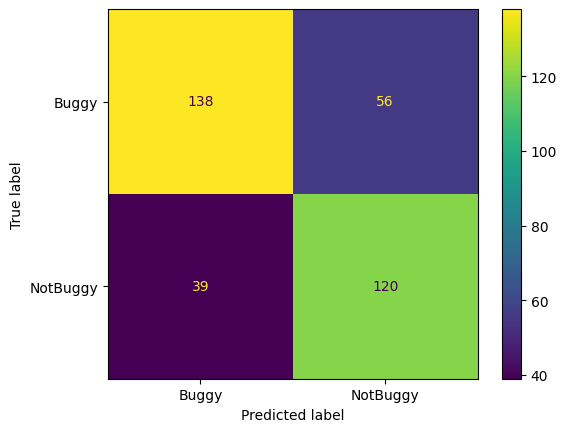

In [8]:
train_test(RandomForestClassifier(random_state=random_seed, n_jobs=-1), "./data/Embeddings/CodeBERTMsgDiff.csv")

### SVC

SVC
Accuracy: 0.6714
Precision: 0.7500
Recall: 0.6031
F1 Score: 0.6686
MCC Score: 0.3585

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.75      0.60      0.67       194
    NotBuggy       0.61      0.75      0.67       159

    accuracy                           0.67       353
   macro avg       0.68      0.68      0.67       353
weighted avg       0.69      0.67      0.67       353



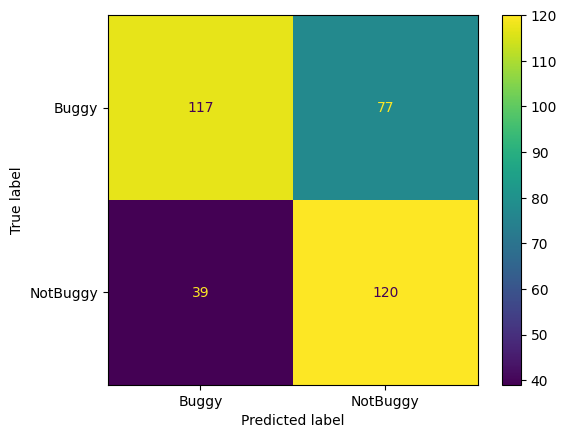

In [9]:
train_test(SVC(random_state=random_seed), "./data/Embeddings/CodeBERTMsgDiff.csv")

### Decision Tree

DecisionTreeClassifier
Accuracy: 0.5977
Precision: 0.6461
Recall: 0.5928
F1 Score: 0.6183
MCC Score: 0.1956

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.65      0.59      0.62       194
    NotBuggy       0.55      0.60      0.57       159

    accuracy                           0.60       353
   macro avg       0.60      0.60      0.60       353
weighted avg       0.60      0.60      0.60       353



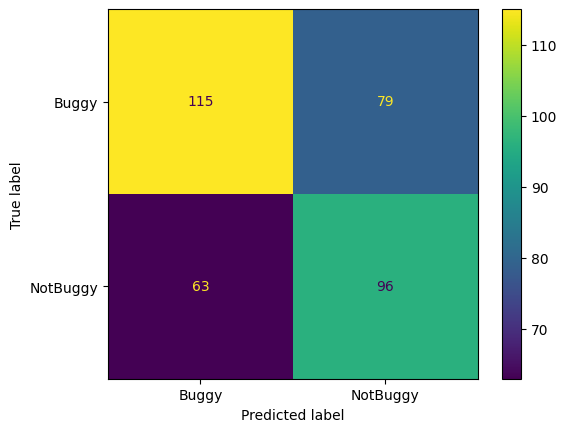

In [10]:
train_test(DecisionTreeClassifier(random_state=random_seed), "./data/Embeddings/CodeBERTMsgDiff.csv")

### MLP

MLPClassifier
Accuracy: 0.7762
Precision: 0.7511
Recall: 0.8866
F1 Score: 0.8132
MCC Score: 0.5504

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.75      0.89      0.81       194
    NotBuggy       0.82      0.64      0.72       159

    accuracy                           0.78       353
   macro avg       0.79      0.76      0.77       353
weighted avg       0.78      0.78      0.77       353



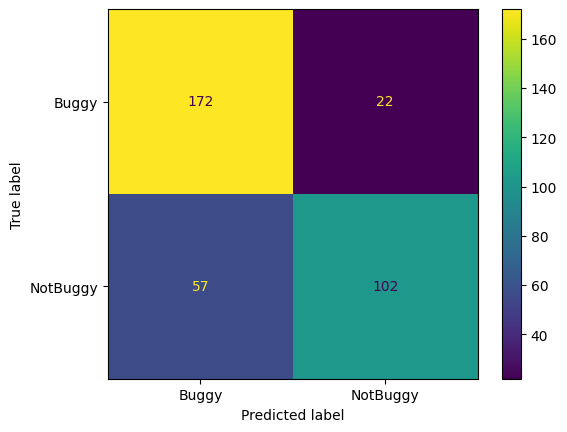

In [6]:
train_test(MLPClassifier(random_state=random_seed), "./data/Embeddings/CodeBERTMsgDiff.csv")

### LOO + MLP

100%|██████████| 1764/1764 [35:41<00:00,  1.21s/it]

Accuracy 0.7647392290249433 
Precision 0.7378832838773491 
Recall 0.8325892857142857 
F1 Score 0.7823807026743577 
MCC 0.5329544930088197

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.74      0.83      0.78       896
    NotBuggy       0.80      0.69      0.74       868

    accuracy                           0.76      1764
   macro avg       0.77      0.76      0.76      1764
weighted avg       0.77      0.76      0.76      1764



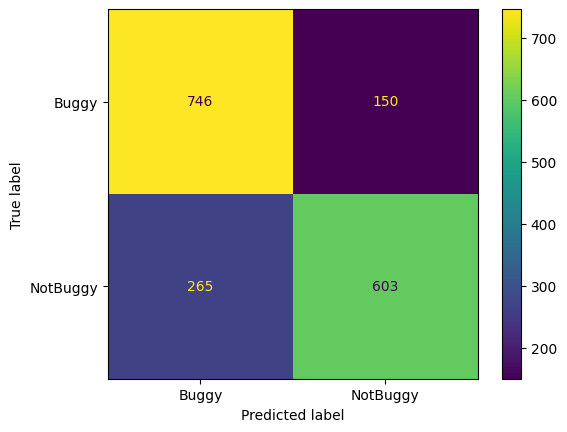

In [45]:
loo(MLPClassifier(random_state=random_seed), "./data/Embeddings/CodeBERTMsgDiff.csv")

## embeddinggemma-300m

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("google/embeddinggemma-300m", device="cuda:0" )
tokenizer = model.tokenizer

def get_embeddings(
    text: str,
    token_limit: int = 2048,  # From Hugging Face model card
    stride: int = 1800
) -> np.ndarray:

    # Tokenize input text
    tokens = tokenizer.encode(text, add_special_tokens=False)
    total_tokens = len(tokens)

    embeddings = []
    start = 0
    while start < total_tokens:
        end = min(start + token_limit, total_tokens)
        chunk_tokens = tokens[start:end]
        chunk_text = tokenizer.decode(chunk_tokens)
        chunk_text = "task: classification | query: " + chunk_text

        # Encode chunk with task type
        emb = model.encode(
            chunk_text,
            convert_to_numpy=True,
            normalize_embeddings=True
        )
        embeddings.append(emb)
        start += stride

    if not embeddings:
        raise ValueError("No embeddings generated — check your input text or model setup.")

    # Mean-pool all embeddings
    pooled_embedding = np.mean(np.vstack(embeddings), axis=0)

    return pooled_embedding

df = pd.read_csv("./data/Complete_GoldSet.csv")
df['text'] = "CommitMessage: " + df['CommitMessage'] + "\nDiff:\n" +  df['Diff']

id = []
X = []
Y = []
for _, row in tqdm(df.iterrows()):
    emb = get_embeddings(row['text'])
    id.append(row["CommitHash"])
    X.append(emb)
    Y.append(row["Decision"])
    
df_emb = pd.DataFrame(data={"Hash": id, "Embeddings": X, "Label": Y})
df_emb['Embeddings'] = df_emb['Embeddings'].astype('object')
df_emb.to_csv("./data/Embeddings/GemmaMsgDiff.csv", index=False)

arr_x = np.array(X)
np.save("./data/Embeddings/GemmaMsgDiff.npy", arr_x)

1764it [00:37, 47.26it/s]


### RandomForest

RandomForestClassifier
Accuracy: 0.7337
Precision: 0.7941
Recall: 0.6959
F1 Score: 0.7418
MCC Score: 0.4737

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.79      0.70      0.74       194
    NotBuggy       0.68      0.78      0.73       159

    accuracy                           0.73       353
   macro avg       0.74      0.74      0.73       353
weighted avg       0.74      0.73      0.73       353



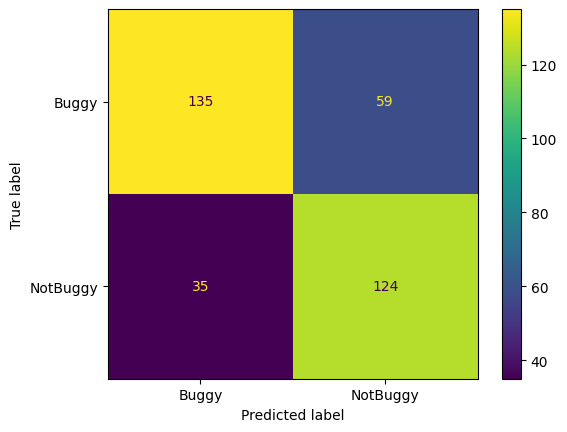

In [4]:
train_test(RandomForestClassifier(random_state=random_seed, n_jobs=-1), "./data/Embeddings/GemmaMsgDiff.csv")

### SVC

SVC
Accuracy: 0.8045
Precision: 0.8531
Recall: 0.7784
F1 Score: 0.8140
MCC Score: 0.6118

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.85      0.78      0.81       194
    NotBuggy       0.76      0.84      0.79       159

    accuracy                           0.80       353
   macro avg       0.80      0.81      0.80       353
weighted avg       0.81      0.80      0.81       353



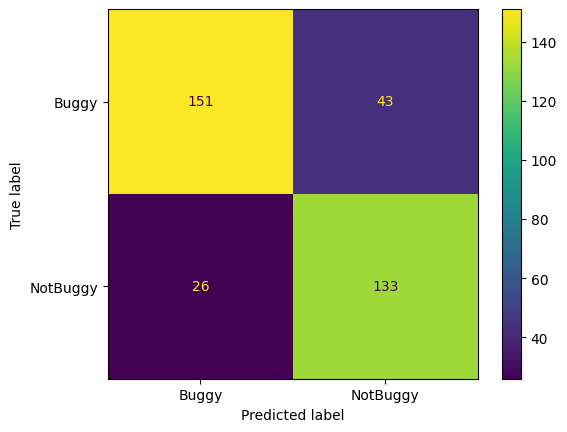

In [5]:
train_test(SVC(random_state=random_seed), "./data/Embeddings/GemmaMsgDiff.csv")

### Decision Tree

DecisionTreeClassifier
Accuracy: 0.5779
Precision: 0.6364
Recall: 0.5412
F1 Score: 0.5850
MCC Score: 0.1634

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.64      0.54      0.58       194
    NotBuggy       0.53      0.62      0.57       159

    accuracy                           0.58       353
   macro avg       0.58      0.58      0.58       353
weighted avg       0.59      0.58      0.58       353



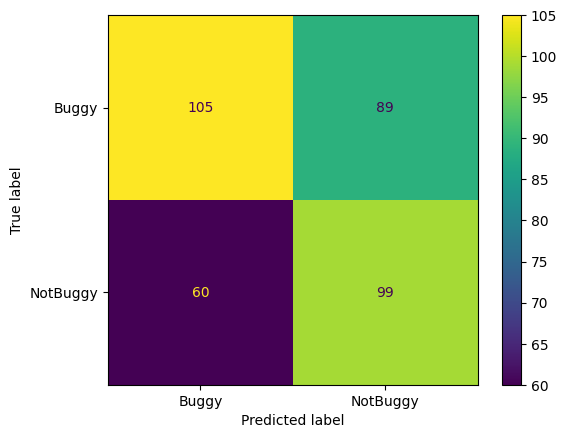

In [6]:
train_test(DecisionTreeClassifier(random_state=random_seed), "./data/Embeddings/GemmaMsgDiff.csv")

### MLP

MLPClassifier
Accuracy: 0.7989
Precision: 0.8154
Recall: 0.8196
F1 Score: 0.8175
MCC Score: 0.5935

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.82      0.82      0.82       194
    NotBuggy       0.78      0.77      0.78       159

    accuracy                           0.80       353
   macro avg       0.80      0.80      0.80       353
weighted avg       0.80      0.80      0.80       353



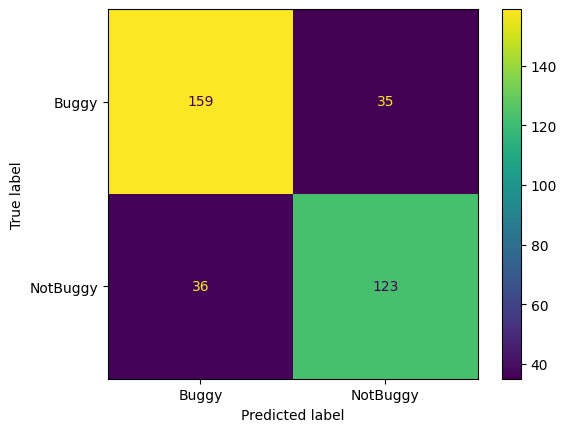

In [7]:
train_test(MLPClassifier(random_state=random_seed), "./data/Embeddings/GemmaMsgDiff.csv")

### LOO + MLP

100%|██████████| 1764/1764 [44:09<00:00,  1.50s/it]

Accuracy 0.8100907029478458 
Precision 0.8162344983089064 
Recall 0.8080357142857143 
F1 Score 0.8121144139091419 
MCC 0.6201795197876697

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.82      0.81      0.81       896
    NotBuggy       0.80      0.81      0.81       868

    accuracy                           0.81      1764
   macro avg       0.81      0.81      0.81      1764
weighted avg       0.81      0.81      0.81      1764



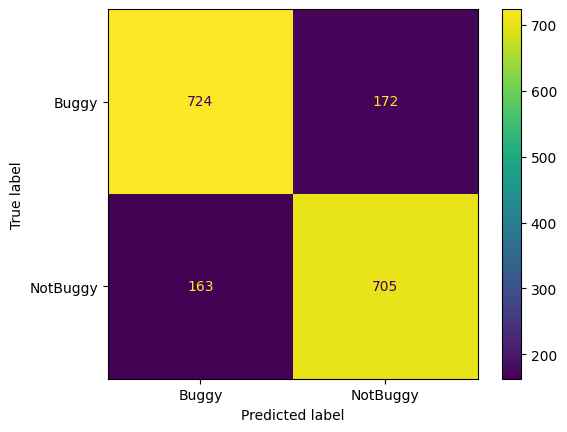

In [43]:
loo(MLPClassifier(random_state=random_seed), "./data/Embeddings/GemmaMsgDiff.csv")

## GraphCodeBERT

In [ ]:
df = pd.read_csv("./data/Complete_GoldSet.csv")
df['text'] = "CommitMessage: " + df['CommitMessage'] + "\nDiff:\n" +  df['Diff']

codebert_egen = CodeBERTEmbeddingGenerator("microsoft/graphcodebert-base")
id = []
X = []
Y = []
for _, row in tqdm(df.iterrows()):
    emb = codebert_egen.get_embeddings(row['CommitMessage'], row['Diff'])
    id.append(row["CommitHash"])
    X.append(emb)
    Y.append(row["Decision"])
    
df_emb = pd.DataFrame(data={"Hash": id, "Embeddings": X, "Label": Y})
df_emb['Embeddings'] = df_emb['Embeddings'].astype('object')
df_emb.to_csv("./data/Embeddings/GraphCodeBERTMsgDiff.csv", index=False)

arr_x = np.array(X)
np.save("./data/Embeddings/GraphCodeBERTMsgDiff.npy", arr_x)

### RandomForest

RandomForestClassifier
Accuracy: 0.7564
Precision: 0.7727
Recall: 0.7887
F1 Score: 0.7806
MCC Score: 0.5069

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.77      0.79      0.78       194
    NotBuggy       0.74      0.72      0.73       159

    accuracy                           0.76       353
   macro avg       0.75      0.75      0.75       353
weighted avg       0.76      0.76      0.76       353



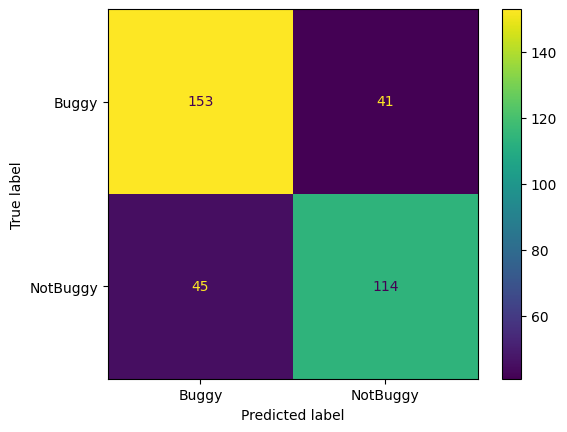

In [16]:
train_test(RandomForestClassifier(random_state=random_seed, n_jobs=-1), "./data/Embeddings/GraphCodeBERTMsgDiff.csv")

### SVC

SVC
Accuracy: 0.8045
Precision: 0.8205
Recall: 0.8247
F1 Score: 0.8226
MCC Score: 0.6050

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.82      0.82      0.82       194
    NotBuggy       0.78      0.78      0.78       159

    accuracy                           0.80       353
   macro avg       0.80      0.80      0.80       353
weighted avg       0.80      0.80      0.80       353



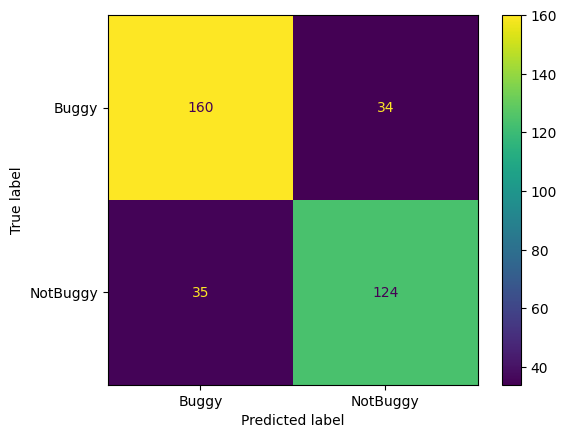

In [17]:
train_test(SVC(random_state=random_seed), "./data/Embeddings/GraphCodeBERTMsgDiff.csv")

### Decision Tree

DecisionTreeClassifier
Accuracy: 0.6856
Precision: 0.7293
Recall: 0.6804
F1 Score: 0.7040
MCC Score: 0.3705

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.73      0.68      0.70       194
    NotBuggy       0.64      0.69      0.66       159

    accuracy                           0.69       353
   macro avg       0.68      0.69      0.68       353
weighted avg       0.69      0.69      0.69       353



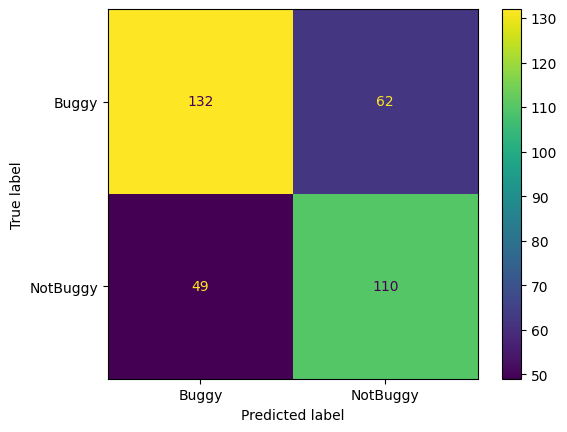

In [18]:
train_test(DecisionTreeClassifier(random_state=random_seed), "./data/Embeddings/GraphCodeBERTMsgDiff.csv")

### MLP

MLPClassifier
Accuracy: 0.8329
Precision: 0.8902
Recall: 0.7938
F1 Score: 0.8392
MCC Score: 0.6711

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.89      0.79      0.84       194
    NotBuggy       0.78      0.88      0.83       159

    accuracy                           0.83       353
   macro avg       0.83      0.84      0.83       353
weighted avg       0.84      0.83      0.83       353



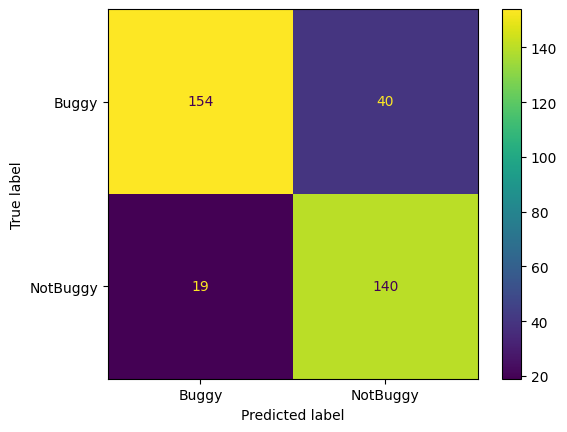

In [19]:
train_test(MLPClassifier(random_state=random_seed), "./data/Embeddings/GraphCodeBERTMsgDiff.csv")

### LOO + MLP

100%|██████████| 1764/1764 [44:46<00:00,  1.52s/it]

Accuracy 0.8282312925170068 
Precision 0.8312849162011173 
Recall 0.8303571428571429 
F1 Score 0.830820770519263 
MCC 0.6563826156594522

Classification Report:
               precision    recall  f1-score   support

       Buggy       0.83      0.83      0.83       896
    NotBuggy       0.83      0.83      0.83       868

    accuracy                           0.83      1764
   macro avg       0.83      0.83      0.83      1764
weighted avg       0.83      0.83      0.83      1764



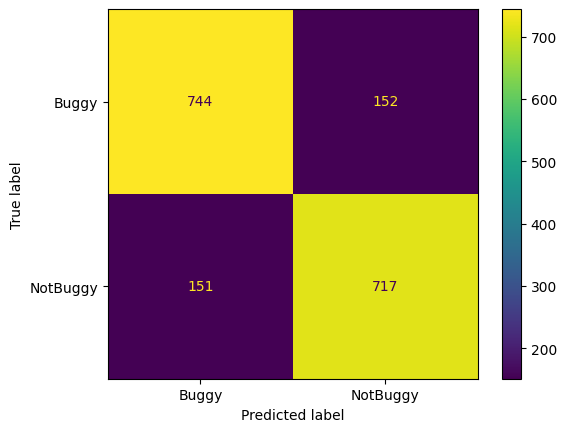

In [44]:
loo(MLPClassifier(random_state=random_seed), "./data/Embeddings/GraphCodeBERTMsgDiff.csv")